# Wine Quality — Model Building

Train and compare 7 classification models on the binary `good_quality` target. Cross-validate, plot ROC curves, and tune the best performer with `GridSearchCV`.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc

import sys
sys.path.append(".")
from utils import (evaluate_model, plot_confusion_matrix,
                   cross_validate_model, compare_models)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = pd.read_csv("data/winequality-red_cleaned.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (1599, 17)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,good_quality,total_acidity,acidity_ratio,free_to_total_sulfur,alcohol_level_medium,alcohol_level_high
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,8.10,10.571429,0.323529,False,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,8.68,8.863636,0.373134,True,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,8.56,10.263158,0.277778,True,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,11.48,40.000000,0.283333,True,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,8.10,10.571429,0.323529,False,False


## 2. Train / Test Split + Scaling

In [3]:
X = df.drop(columns=["good_quality"])
y = df["good_quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train good-rate: {y_train.mean():.3f}, Test good-rate: {y_test.mean():.3f}")

Train: (1279, 16), Test: (320, 16)
Train good-rate: 0.136, Test good-rate: 0.134


## 3. Model 1 — Logistic Regression


  Logistic Regression
  Accuracy    : 0.7937
  Precision   : 0.3678
  Recall      : 0.7442
  F1 Score    : 0.4923


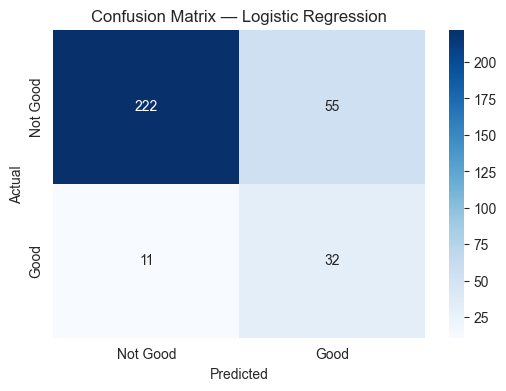

In [4]:
lr = LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
m_lr = evaluate_model("Logistic Regression", y_test, pred_lr)
plot_confusion_matrix(y_test, pred_lr, "Logistic Regression"); plt.show()

## 4. Model 2 — Decision Tree


  Decision Tree
  Accuracy    : 0.8875
  Precision   : 0.5714
  Recall      : 0.6512
  F1 Score    : 0.6087


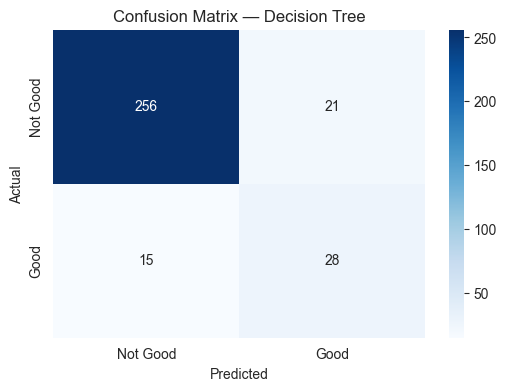

In [5]:
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
m_dt = evaluate_model("Decision Tree", y_test, pred_dt)
plot_confusion_matrix(y_test, pred_dt, "Decision Tree"); plt.show()

## 5. Model 3 — Random Forest


  Random Forest
  Accuracy    : 0.9375
  Precision   : 0.9259
  Recall      : 0.5814
  F1 Score    : 0.7143


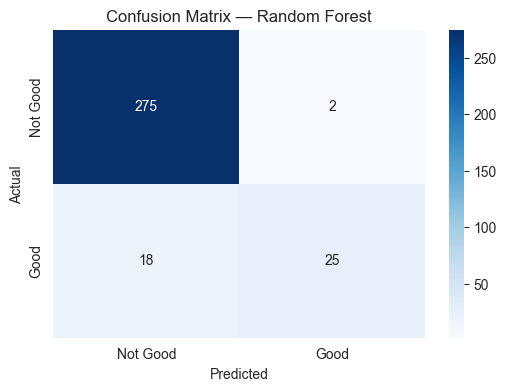

In [6]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
m_rf = evaluate_model("Random Forest", y_test, pred_rf)
plot_confusion_matrix(y_test, pred_rf, "Random Forest"); plt.show()

## 6. Model 4 — KNN (with K optimization)

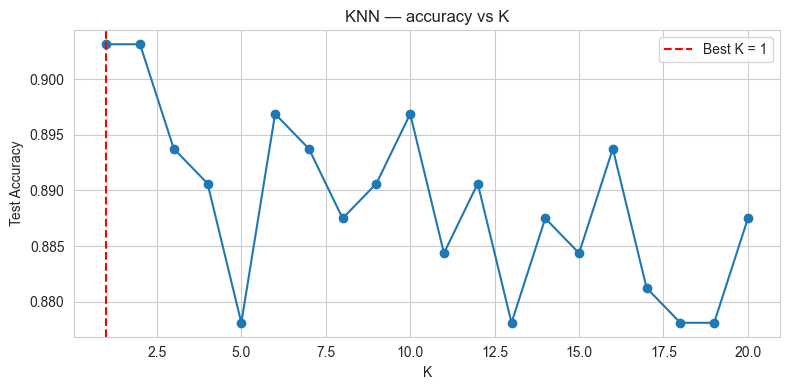


  KNN (K=1)
  Accuracy    : 0.9031
  Precision   : 0.6429
  Recall      : 0.6279
  F1 Score    : 0.6353


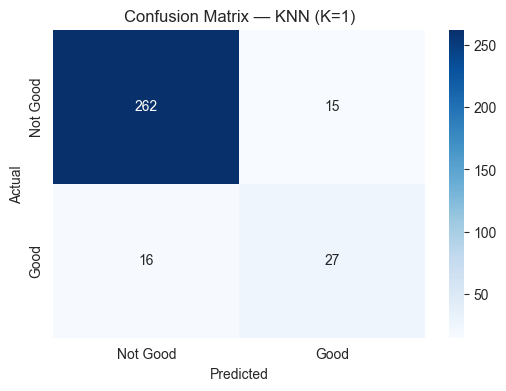

In [7]:
ks = list(range(1, 21))
acc = []
for k in ks:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_s, y_train)
    acc.append(knn_k.score(X_test_s, y_test))

best_k = ks[int(np.argmax(acc))]
plt.figure(figsize=(8, 4))
plt.plot(ks, acc, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.xlabel("K"); plt.ylabel("Test Accuracy"); plt.title("KNN — accuracy vs K")
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
pred_knn = knn.predict(X_test_s)
m_knn = evaluate_model(f"KNN (K={best_k})", y_test, pred_knn)
plot_confusion_matrix(y_test, pred_knn, f"KNN (K={best_k})"); plt.show()

## 7. Model 5 — SVM


  SVM
  Accuracy    : 0.8344
  Precision   : 0.4359
  Recall      : 0.7907
  F1 Score    : 0.5620


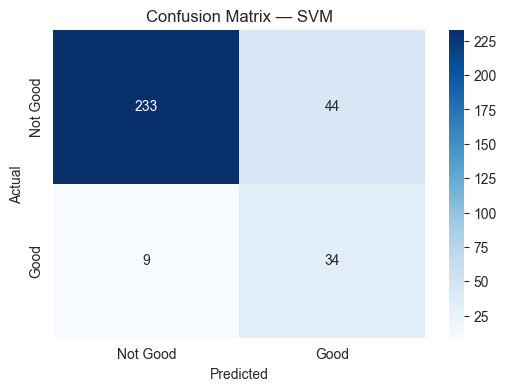

In [8]:
svm = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm.fit(X_train_s, y_train)
pred_svm = svm.predict(X_test_s)
m_svm = evaluate_model("SVM", y_test, pred_svm)
plot_confusion_matrix(y_test, pred_svm, "SVM"); plt.show()

## 8. Model 6 — Gradient Boosting


  Gradient Boosting
  Accuracy    : 0.9094
  Precision   : 0.7500
  Recall      : 0.4884
  F1 Score    : 0.5915


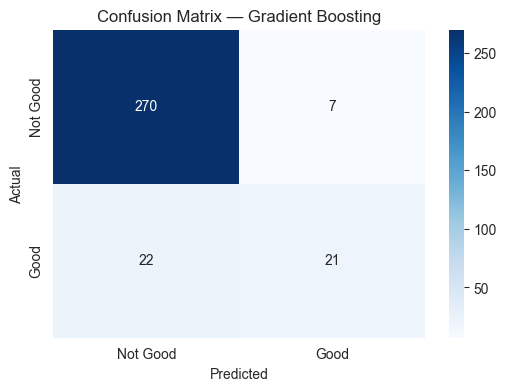

In [9]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
m_gb = evaluate_model("Gradient Boosting", y_test, pred_gb)
plot_confusion_matrix(y_test, pred_gb, "Gradient Boosting"); plt.show()

## 9. Model 7 — Naive Bayes


  Naive Bayes
  Accuracy    : 0.8406
  Precision   : 0.4394
  Recall      : 0.6744
  F1 Score    : 0.5321


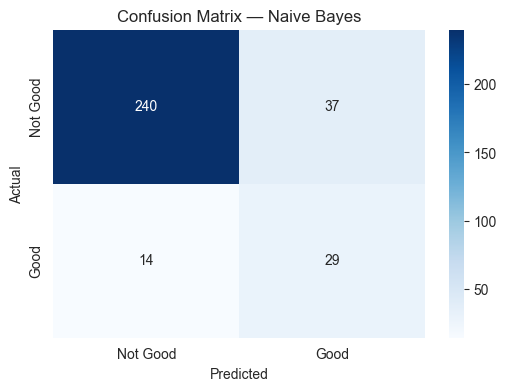

In [10]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)
m_nb = evaluate_model("Naive Bayes", y_test, pred_nb)
plot_confusion_matrix(y_test, pred_nb, "Naive Bayes"); plt.show()

## 10. Feature Importance (tree-based)

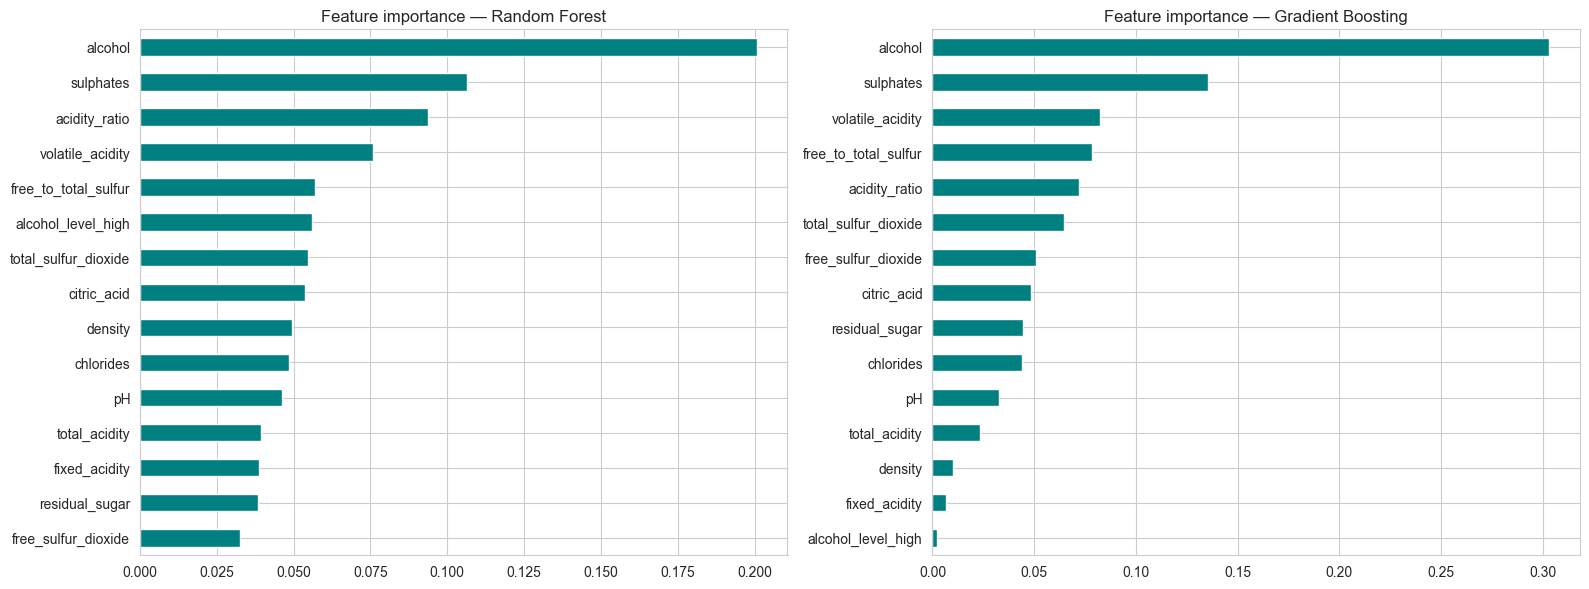

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], gb, "Gradient Boosting")]:
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    imp.tail(15).plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Feature importance — {name}")
plt.tight_layout(); plt.show()

## 11. Model Comparison

In [12]:
results = [m_lr, m_dt, m_rf, m_knn, m_svm, m_gb, m_nb]
df_results = compare_models(results)
df_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.9375,0.9259,0.5814,0.7143
1,KNN (K=1),0.9031,0.6429,0.6279,0.6353
2,Decision Tree,0.8875,0.5714,0.6512,0.6087
3,Gradient Boosting,0.9094,0.7500,0.4884,0.5915
4,SVM,0.8344,0.4359,0.7907,0.5620
5,Naive Bayes,0.8406,0.4394,0.6744,0.5321
6,Logistic Regression,0.7938,0.3678,0.7442,0.4923


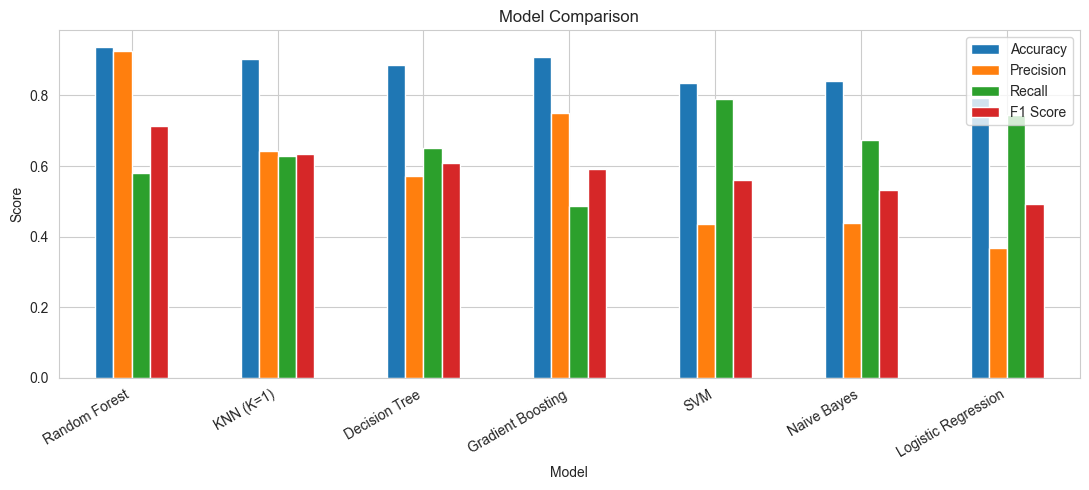

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
df_results.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(kind="bar", ax=ax)
ax.set_title("Model Comparison")
ax.set_ylabel("Score")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 12. 5-Fold Cross-Validation

In [14]:
cv_models = {
    "Logistic Regression": (lr, X_train_s),
    "Decision Tree":       (dt, X_train),
    "Random Forest":       (rf, X_train),
    f"KNN (K={best_k})":   (knn, X_train_s),
    "SVM":                 (svm, X_train_s),
    "Gradient Boosting":   (gb, X_train),
    "Naive Bayes":         (nb, X_train),
}
cv_scores = {}
for name, (m, X_in) in cv_models.items():
    print(f"\n{name}")
    cv_scores[name] = cross_validate_model(m, X_in, y_train, cv=5)


Logistic Regression
  CV F1 Scores : [0.4793 0.5565 0.4286 0.4706 0.4821]
  Mean F1      : 0.4834 (+/- 0.0413)

Decision Tree
  CV F1 Scores : [0.5294 0.4211 0.475  0.5135 0.4789]
  Mean F1      : 0.4836 (+/- 0.0374)

Random Forest


  CV F1 Scores : [0.6071 0.449  0.4815 0.5862 0.5357]
  Mean F1      : 0.5319 (+/- 0.0601)

KNN (K=1)
  CV F1 Scores : [0.4935 0.5946 0.5205 0.5634 0.4706]
  Mean F1      : 0.5285 (+/- 0.0452)

SVM


  CV F1 Scores : [0.4746 0.5556 0.48   0.5391 0.5347]
  Mean F1      : 0.5168 (+/- 0.0330)

Gradient Boosting


  CV F1 Scores : [0.5667 0.3929 0.4375 0.5263 0.4561]
  Mean F1      : 0.4759 (+/- 0.0625)

Naive Bayes
  CV F1 Scores : [0.4752 0.5376 0.3913 0.449  0.4948]
  Mean F1      : 0.4696 (+/- 0.0487)


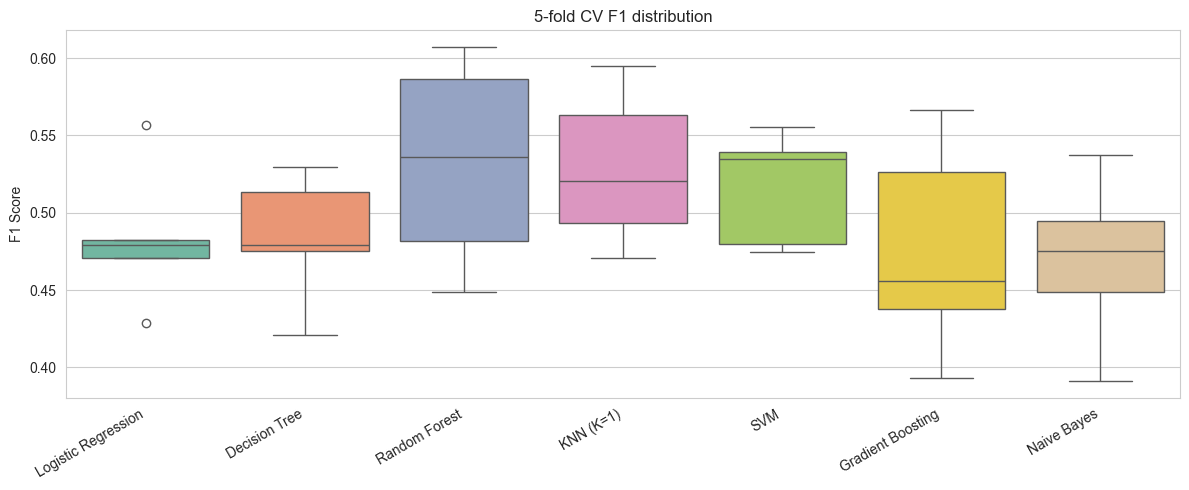

In [15]:
cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize=(12, 5))
sns.boxplot(data=cv_df, palette="Set2")
plt.title("5-fold CV F1 distribution")
plt.xticks(rotation=30, ha="right"); plt.ylabel("F1 Score")
plt.tight_layout(); plt.show()

## 13. ROC Curves

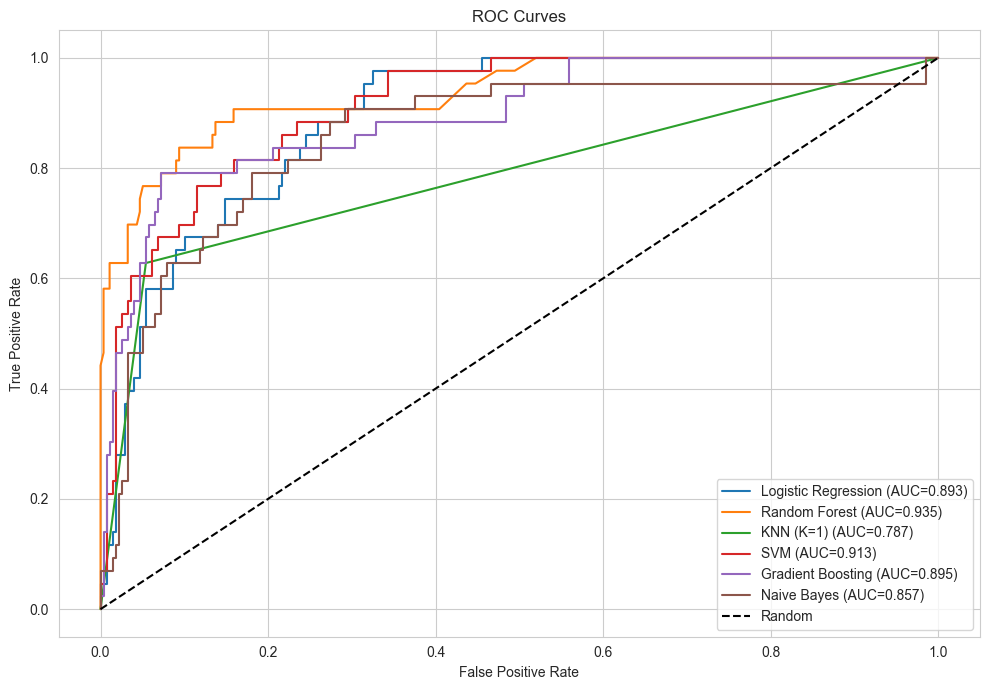

In [16]:
models_for_roc = {
    "Logistic Regression": lr,
    "Random Forest":       rf,
    f"KNN (K={best_k})":   knn,
    "SVM":                 svm,
    "Gradient Boosting":   gb,
    "Naive Bayes":         nb,
}
plt.figure(figsize=(10, 7))
for name, m in models_for_roc.items():
    X_in = X_test_s if name in {"Logistic Regression", f"KNN (K={best_k})", "SVM"} else X_test
    if hasattr(m, "predict_proba"):
        y_prob = m.predict_proba(X_in)[:, 1]
    else:
        y_prob = m.decision_function(X_in)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],"k--", label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 14. Hyperparameter Tuning — Random Forest

In [17]:
param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth":    [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Best params : {grid.best_params_}")
print(f"Best CV F1  : {grid.best_score_:.4f}")

Best params : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1  : 0.5846



  Random Forest (Tuned)
  Accuracy    : 0.9156
  Precision   : 0.7000
  Recall      : 0.6512
  F1 Score    : 0.6747


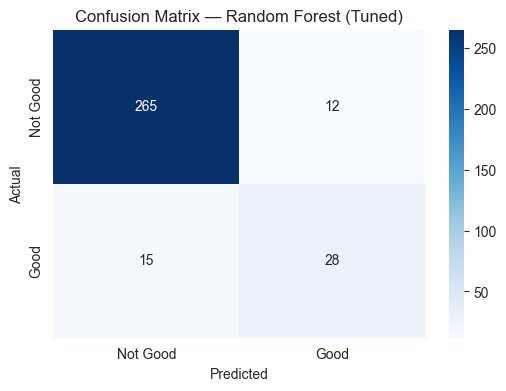

In [18]:
rf_tuned = grid.best_estimator_
pred_rf_t = rf_tuned.predict(X_test)
m_rf_t = evaluate_model("Random Forest (Tuned)", y_test, pred_rf_t)
plot_confusion_matrix(y_test, pred_rf_t, "Random Forest (Tuned)"); plt.show()

## 15. Tuned Feature Importance

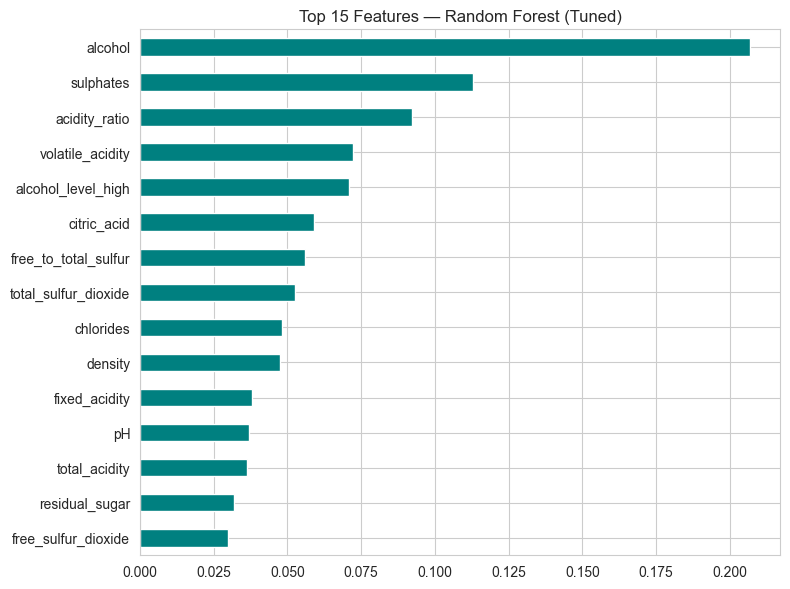

In [19]:
imp = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
imp.tail(15).plot(kind="barh", color="teal")
plt.title("Top 15 Features — Random Forest (Tuned)")
plt.tight_layout(); plt.show()

## 16. Prediction Example

In [20]:
sample = X_test.iloc[[0, 1, 2]]
preds = rf_tuned.predict(sample)
probs = rf_tuned.predict_proba(sample)[:, 1]
for i, (idx, _) in enumerate(sample.iterrows()):
    actual = "Good" if y_test.loc[idx] else "Not Good"
    pred   = "Good" if preds[i] else "Not Good"
    print(f"Sample {i}: actual={actual:8s}  predicted={pred:8s}  P(good)={probs[i]:.3f}")

Sample 0: actual=Not Good  predicted=Not Good  P(good)=0.276
Sample 1: actual=Not Good  predicted=Not Good  P(good)=0.050
Sample 2: actual=Not Good  predicted=Not Good  P(good)=0.016


## 17. Final Summary

| Aspect | Result |
|--------|--------|
| Best baseline | Random Forest / Gradient Boosting (highest F1 on the imbalanced positive class) |
| Tuned model | Random Forest tuned via `GridSearchCV` with `class_weight='balanced'` |
| Top features | `alcohol`, `sulphates`, `volatile_acidity`, `total_sulfur_dioxide`, `density` |
| Class imbalance | ~13.6% positive class — accuracy is misleading; F1 is the right summary metric |

### Next Steps
- Try **SMOTE** or **class-aware threshold tuning** to push recall on the minority "good" class.
- Train on **white wine** (separate UCI file) and compare feature importance.
- Wrap this in a Streamlit demo with sliders for the 11 chemistry features.
- Run **SHAP** or **permutation importance** to confirm the alcohol/volatile-acidity story.